# Ćwiczenia 1: Tabelaryczne uczenie maszynowe w biofizyce (Zbiór ESOL)

W tym ćwiczeniu nauczymy się:
- Podstaw NumPy i Pandas
- Reprezentacji cząsteczek w RDKit i ekstrakcji cech molekularnych
- Podstawowej analizy eksploracyjnej danych (EDA)
- Budowania modeli predykcyjnych z scikit-learn
- Oceny jakości modeli

## Przygotowanie środowiska

### Krok 1: Otwórz terminal

W VS Code: `Terminal` → `New Terminal` (lub skrót `Ctrl+``)

### Krok 2: Utwórz wirtualne środowisko

Przejdź do folderu z ćwiczeniem i utwórz nowe środowisko wirtualne:

```bash
# Przejdź do folderu z ćwiczeniem (dostosuj ścieżkę)
cd /sciezka/do/cwiczenia

# Utwórz wirtualne środowisko o nazwie 'venv'
python -m venv venv
```

### Krok 3: Aktywuj środowisko wirtualne

**Linux / macOS:**
```bash
source venv/bin/activate
```

Po aktywacji powinieneś zobaczyć `(venv)` na początku linii w terminalu.

### Krok 4: Zainstaluj wymagane pakiety

Lub jeśli masz plik `requirements.txt`:
```bash
pip install -r requirements.txt
```

### Krok 5: Wybierz kernel w VS Code

1. Otwórz notebook w VS Code
2. Kliknij na nazwę kernela w prawym górnym rogu (np. "Python 3")
3. Wybierz "venv ..." z listy



In [1]:
# Import bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ustawienia wyświetlania
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')
# %matplotlib inline

---
## 1. Rozgrzewka: NumPy + Pandas

### 1.1 Operacje na tablicach NumPy

In [2]:
# Tworzenie tablic NumPy
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("Tablica a:", a)
print("Tablica b:", b)

Tablica a: [1 2 3 4 5]
Tablica b: [10 20 30 40 50]


In [3]:
# Operacje element-wise (array-wise)
print("a + b =", a + b)        # Dodawanie
print("a * b =", a * b)        # Mnożenie
print("a ** 2 =", a ** 2)      # Potęgowanie
print("np.sqrt(b) =", np.sqrt(b))  # Pierwiastek

a + b = [11 22 33 44 55]
a * b = [ 10  40  90 160 250]
a ** 2 = [ 1  4  9 16 25]
np.sqrt(b) = [3.16227766 4.47213595 5.47722558 6.32455532 7.07106781]


In [4]:
# Tablice 2D
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("Macierz:")
print(matrix)
print("\nKształt:", matrix.shape)

Macierz:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Kształt: (3, 3)


### 1.2 Slicing (wycinanie)

In [5]:
# Slicing tablic 1D
arr = np.arange(10)  # [0, 1, 2, ..., 9]
print("Cała tablica:", arr)
print("Elementy 2-5:", arr[2:6])    # indeksy 2, 3, 4, 5
print("Co drugi element:", arr[::2])  # indeksy 0, 2, 4, 6, 8
print("Ostatnie 3 elementy:", arr[-3:])

Cała tablica: [0 1 2 3 4 5 6 7 8 9]
Elementy 2-5: [2 3 4 5]
Co drugi element: [0 2 4 6 8]
Ostatnie 3 elementy: [7 8 9]


In [6]:
# Slicing tablic 2D
print("Cała macierz:")
print(matrix)
print("\nPierwszy wiersz:", matrix[0, :])      # lub matrix[0]
print("Pierwsza kolumna:", matrix[:, 0])
print("Podmacierz 2x2 (prawy dolny róg):")
print(matrix[1:, 1:])

Cała macierz:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Pierwszy wiersz: [1 2 3]
Pierwsza kolumna: [1 4 7]
Podmacierz 2x2 (prawy dolny róg):
[[5 6]
 [8 9]]


### 1.3 Konwersja NumPy <-> Pandas

In [7]:
# NumPy -> Pandas DataFrame
data_np = np.random.randn(5, 3)  # 5 wierszy, 3 kolumny
df = pd.DataFrame(data_np, columns=['A', 'B', 'C'])
print("DataFrame z NumPy:")
df

DataFrame z NumPy:


,A,B,C
0,1.935975,0.760150,-0.088275
1,-0.950879,0.617312,-0.593474
2,-0.200465,-0.039958,-0.027293
3,-2.092732,0.909640,0.433127
4,0.176926,1.775037,1.141195


In [8]:
# Pandas -> NumPy
back_to_np = df.values  # lub df.to_numpy()
print("Powrót do NumPy:")
print(back_to_np)
print("\nTyp:", type(back_to_np))

Powrót do NumPy:
[[ 1.93597475  0.76015002 -0.08827473]
 [-0.95087855  0.61731179 -0.59347434]
 [-0.20046518 -0.03995798 -0.02729255]
 [-2.09273183  0.9096403   0.43312656]
 [ 0.17692575  1.77503744  1.14119549]]

Typ: <class 'numpy.ndarray'>


### 1.4 Operacje na kolumnach Pandas

In [9]:
# Tworzenie przykładowego DataFrame
df_example = pd.DataFrame({
    'nazwa': ['mol_1', 'mol_2', 'mol_3', 'mol_4', 'mol_5'],
    'masa': [180.5, 220.3, 150.1, 310.8, 95.2],
    'logP': [2.1, 3.5, 1.2, 4.8, 0.5],
    'aktywny': [True, True, False, True, False]
})
df_example

,nazwa,masa,logP,aktywny
0,mol_1,180.5,2.1,True
1,mol_2,220.3,3.5,True
2,mol_3,150.1,1.2,False
3,mol_4,310.8,4.8,True
4,mol_5,95.2,0.5,False


In [10]:
# Dostęp do kolumn
print("Kolumna 'masa':")
print(df_example['masa'])

print("\nKilka kolumn:")
print(df_example[['nazwa', 'logP']])

Kolumna 'masa':
0    180.5
1    220.3
2    150.1
3    310.8
4     95.2
Name: masa, dtype: float64

Kilka kolumn:
   nazwa  logP
0  mol_1   2.1
1  mol_2   3.5
2  mol_3   1.2
3  mol_4   4.8
4  mol_5   0.5


In [11]:
# Dodawanie nowej kolumny
df_example['masa_kg'] = df_example['masa'] / 1000
df_example

,nazwa,masa,logP,aktywny,masa_kg
0,mol_1,180.5,2.1,True,0.1805
1,mol_2,220.3,3.5,True,0.2203
2,mol_3,150.1,1.2,False,0.1501
3,mol_4,310.8,4.8,True,0.3108
4,mol_5,95.2,0.5,False,0.0952


### 1.5 Filtrowanie wierszy według warunku

In [12]:
# Filtrowanie według pojedynczego warunku
print("Cząsteczki o masie > 200:")
df_example[df_example['masa'] > 200]

Cząsteczki o masie > 200:


,nazwa,masa,logP,aktywny,masa_kg
1,mol_2,220.3,3.5,True,0.2203
3,mol_4,310.8,4.8,True,0.3108


In [13]:
# Filtrowanie według wielu warunków
print("Aktywne cząsteczki o logP > 2:")
df_example[(df_example['aktywny'] == True) & (df_example['logP'] > 2)]

Aktywne cząsteczki o logP > 2:


,nazwa,masa,logP,aktywny,masa_kg
0,mol_1,180.5,2.1,True,0.1805
1,mol_2,220.3,3.5,True,0.2203
3,mol_4,310.8,4.8,True,0.3108


### Zadanie 1

Utwórz tablicę NumPy zawierającą liczby od 1 do 20. Następnie:
1. Wybierz tylko liczby parzyste (użyj slicingu lub warunku)
2. Oblicz sumę kwadratów tych liczb
3. Przekonwertuj wynik na DataFrame z kolumną 'kwadraty'

In [14]:
# Twoje rozwiązanie tutaj


---
## 2. Przygotowanie danych - reprezentacja cząsteczek w RDKit

### 2.1 Wczytanie zbioru danych

Użyjemy zbioru danych zawierającego cząsteczki i ich właściwości biologiczne. Dla uproszczenia stworzymy przykładowy zbiór z kilkoma lekami.

In [15]:
# Przykładowy zbiór danych - znane leki i ich rozpuszczalność (logS)
data = {
    'name': ['Aspirin', 'Caffeine', 'Ibuprofen', 'Paracetamol', 'Diazepam',
             'Warfarin', 'Metformin', 'Omeprazole', 'Atorvastatin', 'Lisinopril',
             'Amlodipine', 'Metoprolol', 'Simvastatin', 'Losartan', 'Gabapentin',
             'Sertraline', 'Fluoxetine', 'Clopidogrel', 'Pantoprazole', 'Ranitidine'],
    'smiles': [
        'CC(=O)OC1=CC=CC=C1C(=O)O',  # Aspirin
        'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',  # Caffeine
        'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',  # Ibuprofen
        'CC(=O)NC1=CC=C(C=C1)O',  # Paracetamol
        'CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3',  # Diazepam
        'CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O',  # Warfarin
        'CN(C)C(=N)NC(=N)N',  # Metformin
        'CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=C(N2)C=CC(=C3)OC',  # Omeprazole
        'CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4',  # Atorvastatin
        'NCCCC[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1CCC[C@H]1C(=O)O',  # Lisinopril  
        'CCOC(=O)C1=C(NC(=C(C1C2=CC=CC=C2Cl)C(=O)OC)C)COCCN',  # Amlodipine
        'CC(C)NCC(COC1=CC=C(C=C1)CCOC)O',  # Metoprolol
        'CCC(C)(C)C(=O)OC1CC(C=C2C1C(C(C=C2)C)CCC3CC(CC(=O)O3)O)C',  # Simvastatin
        'CCCCC1=NC(=C(N1CC2=CC=C(C=C2)C3=CC=CC=C3C4=NNN=N4)CO)Cl',  # Losartan
        'NCC1(CCCCC1)CC(=O)O',  # Gabapentin
        'CNC1CCC(C2=CC=CC=C12)C3=CC(=C(C=C3)Cl)Cl',  # Sertraline
        'CNCCC(C1=CC=CC=C1)OC2=CC=C(C=C2)C(F)(F)F',  # Fluoxetine
        'COC(=O)C(C1=CC=CS1)C2CC3=C(C=CC=C3N2)Cl',  # Clopidogrel
        'COC1=CC=NC2=C1N=C(N2S(=O)C3=CC=C(C=C3)OC)C(F)(F)F',  # Pantoprazole
        'CNC(=C[N+](=O)[O-])NCCSCC1=CC=C(O1)CN(C)C'  # Ranitidine
    ],
    'logS': [-2.3, -0.5, -4.0, -1.0, -3.8, -4.5, 0.8, -3.2, -6.5, -1.2,
             -3.8, -1.5, -5.8, -4.2, -0.9, -5.1, -4.6, -4.8, -3.5, -1.8]  # log(rozpuszczalność w mol/L)
}

df = pd.DataFrame(data)
print(f"Liczba cząsteczek: {len(df)}")
df.head()

Liczba cząsteczek: 20


,name,smiles,logS
0,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,-2.3
1,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,-0.5
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,-4.0
3,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,-1.0
4,Diazepam,CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3,-3.8


### 2.2 Reprezentacja cząsteczek w RDKit

In [16]:
# Konwersja SMILES do obiektów molekuł RDKit
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)

# Sprawdzenie czy wszystkie cząsteczki zostały poprawnie wczytane
valid_mols = df['mol'].notna().sum()
print(f"Poprawnie wczytane cząsteczki: {valid_mols}/{len(df)}")

Poprawnie wczytane cząsteczki: 20/20


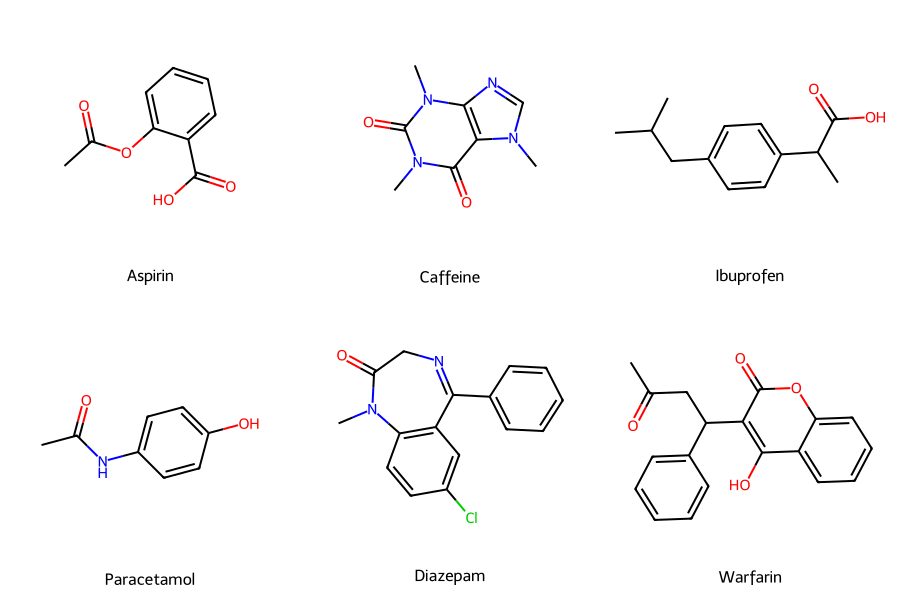

In [17]:
# Wizualizacja kilku cząsteczek
mols_to_draw = df['mol'].head(6).tolist()
names_to_draw = df['name'].head(6).tolist()

img = Draw.MolsToGridImage(mols_to_draw, molsPerRow=3, subImgSize=(300, 300), 
                           legends=names_to_draw)
img

In [18]:
# cząsteczka jako obiekt RDKit
mol = df['mol'][0]  # Pierwsza cząsteczka (Aspirin)

print("Obiekt cząsteczki:", type(mol))

print("Atomy w cząsteczce:")
print([atom.GetSymbol() for atom in mol.GetAtoms()])
print("\nWiązania w cząsteczce:")
for bond in mol.GetBonds():
    begin_atom = bond.GetBeginAtom().GetSymbol()
    end_atom = bond.GetEndAtom().GetSymbol()
    bond_type = bond.GetBondType()
    print(f'{begin_atom}-{end_atom}: {bond_type}')


Obiekt cząsteczki: <class 'rdkit.Chem.rdchem.Mol'>
Atomy w cząsteczce:
['C', 'C', 'O', 'O', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'O']

Wiązania w cząsteczce:
C-C: SINGLE
C-O: DOUBLE
C-O: SINGLE
O-C: SINGLE
C-C: AROMATIC
C-C: AROMATIC
C-C: AROMATIC
C-C: AROMATIC
C-C: AROMATIC
C-C: SINGLE
C-O: DOUBLE
C-O: SINGLE
C-C: AROMATIC


### 2.3 Ekstrakcja cech molekularnych (deskryptorów)

RDKit pozwala obliczyć wiele deskryptorów molekularnych, które opisują właściwości fizykochemiczne cząsteczek.

In [19]:
# Ekstrakcja kilku podstawowych deskryptorów
df['MolWt'] = df['mol'].apply(Descriptors.MolWt)  # Masa molowa
df['LogP'] = df['mol'].apply(Descriptors.MolLogP)  # Współczynnik podziału
df['NumHDonors'] = df['mol'].apply(Descriptors.NumHDonors)  # Donory wiązań wodorowych
df['NumHAcceptors'] = df['mol'].apply(Descriptors.NumHAcceptors)  # Akceptory wiązań wodorowych
df['TPSA'] = df['mol'].apply(Descriptors.TPSA)  # Topological Polar Surface Area

df[['name', 'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']].head(10)

,name,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA
0,Aspirin,180.159,1.31010,1,3,63.60
1,Caffeine,194.194,-1.02930,0,6,61.82
2,Ibuprofen,206.285,3.07320,1,1,37.30
3,Paracetamol,151.165,1.35060,2,2,49.33
4,Diazepam,284.746,3.15380,0,2,32.67
5,Warfarin,308.333,3.60960,1,4,67.51
6,Metformin,129.167,-1.03416,4,2,88.99
7,Omeprazole,345.424,2.89974,1,5,77.10
8,Atorvastatin,558.650,6.31360,4,5,111.79
9,Lisinopril,405.495,1.23520,4,5,132.96


In [20]:
# Ekstrakcja wielu deskryptorów naraz
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

# Lista wszystkich dostępnych deskryptorów
descriptor_names = [desc[0] for desc in Descriptors.descList]
print(f"Liczba dostępnych deskryptorów: {len(descriptor_names)}")
print(f"\nPrzykładowe deskryptory: {descriptor_names[:10]}")

Liczba dostępnych deskryptorów: 217

Przykładowe deskryptory: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons']


In [21]:
# Wybierzemy podzbiór użytecznych deskryptorów
selected_descriptors = [
    'MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
    'NumRotatableBonds', 'NumAromaticRings', 'NumAliphaticRings',
    'RingCount', 'FractionCSP3', 'HeavyAtomCount', 'NumValenceElectrons',
    'MolMR', 'LabuteASA', 'BalabanJ'
]

# Kalkulator deskryptorów
calc = MoleculeDescriptors.MolecularDescriptorCalculator(selected_descriptors)

# Obliczenie deskryptorów dla wszystkich cząsteczek
descriptors_data = []
for mol in df['mol']:
    descriptors_data.append(calc.CalcDescriptors(mol))

# Utworzenie DataFrame z deskryptorami
df_descriptors = pd.DataFrame(descriptors_data, columns=selected_descriptors)
df_descriptors.head()

,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,RingCount,FractionCSP3,HeavyAtomCount,NumValenceElectrons,MolMR,LabuteASA,BalabanJ
0,180.159,1.3101,1,3,63.60,2,1,0,1,0.111111,13,68,44.7103,74.757053,3.043527
1,194.194,-1.0293,0,6,61.82,0,2,0,2,0.375000,14,74,51.1960,79.028957,3.221281
2,206.285,3.0732,1,1,37.30,4,1,0,1,0.461538,15,82,61.0348,90.941754,2.759037
3,151.165,1.3506,2,2,49.33,1,1,0,1,0.125000,11,58,42.4105,64.666905,2.736298
4,284.746,3.1538,0,2,32.67,1,2,1,3,0.125000,20,100,81.8100,122.062379,2.229963


In [22]:
# Połączenie z oryginalnymi danymi
df_full = pd.concat([df[['name', 'smiles', 'logS']], df_descriptors], axis=1)
print(f"Wymiary końcowego zbioru: {df_full.shape}")
df_full.head()

Wymiary końcowego zbioru: (20, 18)


,name,smiles,logS,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,RingCount,FractionCSP3,HeavyAtomCount,NumValenceElectrons,MolMR,LabuteASA,BalabanJ
0,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,-2.3,180.159,1.3101,1,3,63.60,2,1,0,1,0.111111,13,68,44.7103,74.757053,3.043527
1,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,-0.5,194.194,-1.0293,0,6,61.82,0,2,0,2,0.375000,14,74,51.1960,79.028957,3.221281
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,-4.0,206.285,3.0732,1,1,37.30,4,1,0,1,0.461538,15,82,61.0348,90.941754,2.759037
3,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,-1.0,151.165,1.3506,2,2,49.33,1,1,0,1,0.125000,11,58,42.4105,64.666905,2.736298
4,Diazepam,CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3,-3.8,284.746,3.1538,0,2,32.67,1,2,1,3,0.125000,20,100,81.8100,122.062379,2.229963


### 2.4 Finegerprint-y

In [23]:
from rdkit.Chem import MACCSkeys, AllChem


In [24]:
# Metoda słownikowa - MACCS keys
maccs_descriptors = []
for mol in df['mol']:
    maccs_descriptors.append(list(MACCSkeys.GenMACCSKeys(mol)))

df_maccs = pd.concat([df[['name', 'smiles', 'logS']], pd.DataFrame(maccs_descriptors)], axis=1)

df_maccs.head()

,name,smiles,logS,0,1,2,3,4,5,6,...,157,158,159,160,161,162,163,164,165,166
0,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,-2.3,0,0,0,0,0,0,0,...,1,0,1,1,0,1,1,1,1,0
1,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,-0.5,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,-4.0,0,0,0,0,0,0,0,...,1,0,1,1,0,1,1,1,1,0
3,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,-1.0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
4,Diazepam,CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3,-3.8,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,1,1,0


In [25]:
# Metoda hashowa, oparta na fragmentach - Morgan fingerprints

morgan_descriptors = []
fingerprint_generator = AllChem.GetMorganGenerator(radius=4, fpSize=2048)

for mol in df['mol']:
    fingerprint = fingerprint_generator.GetFingerprint(mol)
    morgan_descriptors.append(list(fingerprint))


df_morgan = pd.concat([df[['name', 'smiles', 'logS']], pd.DataFrame(morgan_descriptors)], axis=1)
df_morgan.head()


,name,smiles,logS,0,1,2,3,4,5,6,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,-2.3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,-0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,-4.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,-1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Diazepam,CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3,-3.8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Zadanie 2
Oblicz descryptory Lipińskiego

In [26]:
# Twoje rozwiązanie tutaj
lipinski_descriptors = [(name, desc) for (name, desc) in Descriptors._descList if 'Lipinski' in desc.__module__]

### 2.5 Zbiór danych ESOL

Teraz pobierzemy rzeczywisty zbiór danych ESOL (solubility) z platformy HuggingFace. https://huggingface.co/datasets/scikit-fingerprints/MoleculeNet_ESOL

Utworzenie katalogu "dane"

```
mkdir -p dane
```

Pobranie zbioru danych
```
curl -L https://huggingface.co/datasets/scikit-fingerprints/MoleculeNet_ESOL/raw/main/esol.csv > dane/esol.csv
```

In [27]:
df_esol = pd.read_csv('dane/esol.csv')
df_esol.rename(columns={'SMILES': 'smiles', 'label': 'logS'}, inplace=True)
df_esol.head()


,smiles,logS
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [28]:
# Powtórzenie ekstrakcji cech dla zbioru ESOL
df_esol['mol'] = df_esol['smiles'].apply(Chem.MolFromSmiles)

# Usunięcie ew. błędnych molekuł
df_esol = df_esol.dropna(subset=['mol']).reset_index(drop=True)

# Obliczenie deskryptorów dla zbioru ESOL
descriptors_data_esol = []
for mol in df_esol['mol']:
    descriptors_data_esol.append(calc.CalcDescriptors(mol))

df_descriptors_esol = pd.DataFrame(descriptors_data_esol, columns=selected_descriptors)

# Połączenie, nadpisanie df_full, żeby kolejne kroki działały z nowym zbiorem
df_full = pd.concat([df_esol[['smiles', 'logS']], df_descriptors_esol], axis=1)
df_full['name'] = [f"mol_{i}" for i in range(len(df_full))]  # sztuczna kolumna name

print(f"Wymiary zbioru ESOL z deskryptorami: {df_full.shape}")
df_full.head()

Wymiary zbioru ESOL z deskryptorami: (1128, 18)


,smiles,logS,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,RingCount,FractionCSP3,HeavyAtomCount,NumValenceElectrons,MolMR,LabuteASA,BalabanJ,name
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,7,12,202.32,7,1,2,3,0.650000,32,178,102.2816,182.935327,1.654937,mol_0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,1,2,42.24,2,2,0,2,0.083333,15,76,57.8402,87.724095,2.148162,mol_1
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,0,1,17.07,4,0,0,0,0.500000,11,62,48.4860,68.806046,3.625760,mol_2
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,0,0,0.00,0,5,0,5,0.000000,22,102,96.4660,128.158061,2.041379,mol_3
4,c1ccsc1,-1.33,84.143,1.74810,0,1,0.00,0,1,0,1,0.000000,5,26,24.3190,35.071766,3.125000,mol_4


---
## 3. Analiza eksploracyjna - EDA (Exploratory Data Analysis)

### 3.1 Podsumowanie statystyczne

In [29]:
# Podstawowe statystyki
df_full.describe()

,logS,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,RingCount,FractionCSP3,HeavyAtomCount,NumValenceElectrons,MolMR,LabuteASA,BalabanJ
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-3.050102,203.937074,2.447520,0.701241,2.111702,34.872881,2.177305,0.930851,0.460106,1.390957,0.444395,13.289894,72.056738,54.015959,83.332056,2.676185
std,2.096441,102.738077,1.852875,1.089727,2.153375,35.383593,2.640974,1.005136,1.046482,1.318286,0.374980,6.878603,36.153822,25.279302,40.438188,0.573413
min,-11.600000,16.043000,-7.571400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8.000000,6.731000,8.739251,0.000000
25%,-4.317500,121.183000,1.414900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,8.000000,44.000000,34.415500,51.723137,2.304981
50%,-2.860000,182.179000,2.339000,0.000000,2.000000,26.300000,1.000000,1.000000,0.000000,1.000000,0.357143,12.000000,64.000000,48.522900,73.135436,2.722818
75%,-1.600000,270.372000,3.402200,1.000000,3.000000,55.440000,3.000000,2.000000,0.000000,2.000000,0.800000,18.000000,94.000000,72.258450,111.841822,3.031610
max,1.580000,780.949000,10.388600,11.000000,16.000000,268.680000,23.000000,7.000000,8.000000,8.000000,1.000000,55.000000,312.000000,192.610800,323.322425,4.807811


In [30]:
# Informacje o typach danych i brakujących wartościach
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   smiles               1128 non-null   object 
 1   logS                 1128 non-null   float64
 2   MolWt                1128 non-null   float64
 3   MolLogP              1128 non-null   float64
 4   NumHDonors           1128 non-null   int64  
 5   NumHAcceptors        1128 non-null   int64  
 6   TPSA                 1128 non-null   float64
 7   NumRotatableBonds    1128 non-null   int64  
 8   NumAromaticRings     1128 non-null   int64  
 9   NumAliphaticRings    1128 non-null   int64  
 10  RingCount            1128 non-null   int64  
 11  FractionCSP3         1128 non-null   float64
 12  HeavyAtomCount       1128 non-null   int64  
 13  NumValenceElectrons  1128 non-null   int64  
 14  MolMR                1128 non-null   float64
 15  LabuteASA            1128 non-null   f

In [31]:
# Statystyka brakujących wartości
missing = df_full.isnull().sum()
missing_pct = (missing / len(df_full)) * 100
missing_df = pd.DataFrame({'brakujące': missing, 'procent': missing_pct})
missing_df[missing_df['brakujące'] > 0]

,brakujące,procent


### 3.2 Histogramy i outliers

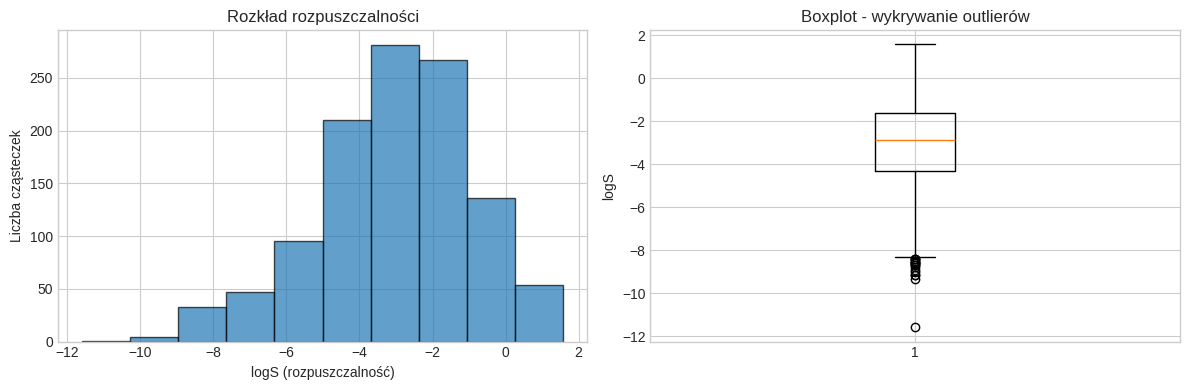

In [32]:
# Histogram zmiennej docelowej (logS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_full['logS'], bins=10, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('logS (rozpuszczalność)')
axes[0].set_ylabel('Liczba cząsteczek')
axes[0].set_title('Rozkład rozpuszczalności')

axes[1].boxplot(df_full['logS'])
axes[1].set_ylabel('logS')
axes[1].set_title('Boxplot - wykrywanie outlierów')

plt.tight_layout()
plt.show()

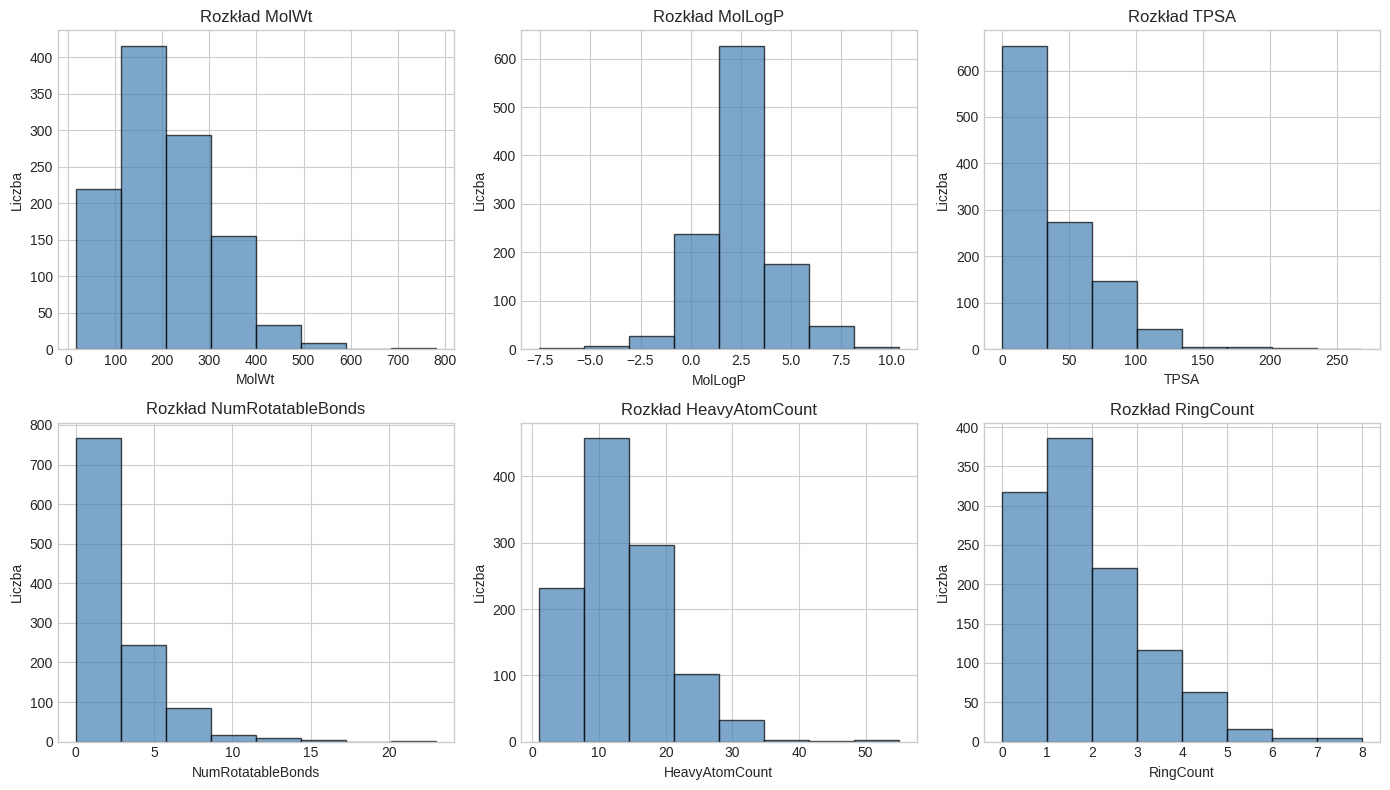

In [33]:
# Histogramy wybranych deskryptorów
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features_to_plot = ['MolWt', 'MolLogP', 'TPSA', 'NumRotatableBonds', 'HeavyAtomCount', 'RingCount']

for i, feature in enumerate(features_to_plot):
    axes[i].hist(df_full[feature], bins=8, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Liczba')
    axes[i].set_title(f'Rozkład {feature}')

plt.tight_layout()
plt.show()

### 3.3 Korelacja zmiennych

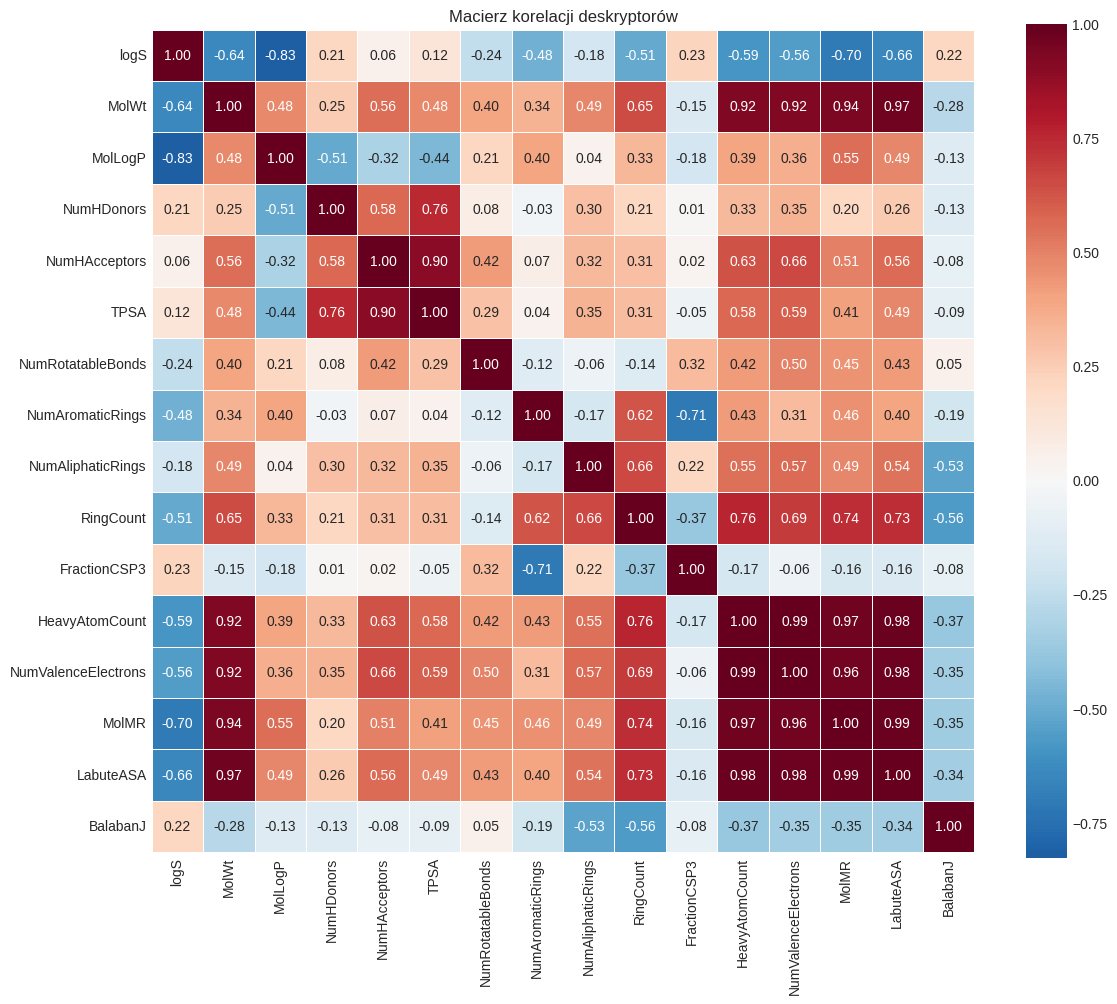

In [34]:
# Macierz korelacji
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
correlation_matrix = df_full[numeric_cols].corr()

# Heatmapa korelacji
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Macierz korelacji deskryptorów')
plt.tight_layout()
plt.show()

In [35]:
# Korelacja deskryptorów ze zmienną docelową
target_corr = correlation_matrix['logS'].drop('logS').sort_values(key=abs, ascending=False)
print("Korelacja deskryptorów z logS (rozpuszczalnością):")
print(target_corr)

Korelacja deskryptorów z logS (rozpuszczalnością):
MolLogP               -0.827918
MolMR                 -0.699756
LabuteASA             -0.655502
MolWt                 -0.640189
HeavyAtomCount        -0.585638
NumValenceElectrons   -0.555686
RingCount             -0.512279
NumAromaticRings      -0.483470
NumRotatableBonds     -0.244256
FractionCSP3           0.228183
BalabanJ               0.220768
NumHDonors             0.209429
NumAliphaticRings     -0.180966
TPSA                   0.123210
NumHAcceptors          0.055728
Name: logS, dtype: float64


array([[<Axes: xlabel='MolLogP', ylabel='MolLogP'>,
        <Axes: xlabel='MolMR', ylabel='MolLogP'>,
        <Axes: xlabel='LabuteASA', ylabel='MolLogP'>,
        <Axes: xlabel='logS', ylabel='MolLogP'>],
       [<Axes: xlabel='MolLogP', ylabel='MolMR'>,
        <Axes: xlabel='MolMR', ylabel='MolMR'>,
        <Axes: xlabel='LabuteASA', ylabel='MolMR'>,
        <Axes: xlabel='logS', ylabel='MolMR'>],
       [<Axes: xlabel='MolLogP', ylabel='LabuteASA'>,
        <Axes: xlabel='MolMR', ylabel='LabuteASA'>,
        <Axes: xlabel='LabuteASA', ylabel='LabuteASA'>,
        <Axes: xlabel='logS', ylabel='LabuteASA'>],
       [<Axes: xlabel='MolLogP', ylabel='logS'>,
        <Axes: xlabel='MolMR', ylabel='logS'>,
        <Axes: xlabel='LabuteASA', ylabel='logS'>,
        <Axes: xlabel='logS', ylabel='logS'>]], dtype=object)

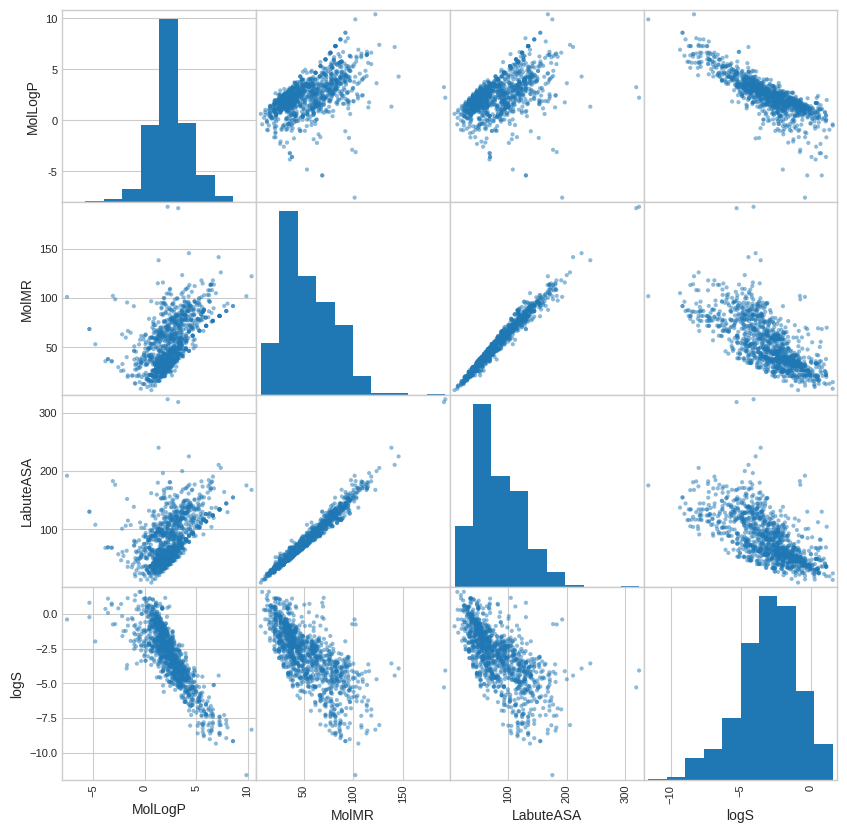

In [36]:
# Scatter plot dla najbardziej skorelowanych zmiennych

top_corr_features = target_corr.head(3).index.tolist()

pd.plotting.scatter_matrix(df_full[top_corr_features + ['logS']], figsize=(10, 10))# plt.show()


### 3.4 Uwaga o usuwaniu zmiennych skorelowanych

W praktyce warto rozważyć usunięcie zmiennych silnie ze sobą skorelowanych (np. |r| > 0.9), ponieważ:
- Wprowadzają redundancję do modelu
- Mogą powodować problemy z interpretowalnością
- Mogą prowadzić do niestabilności niektórych modeli

Popularne metody to:
- **PCA** (Principal Component Analysis) - redukcja wymiarowości
- **Variance Inflation Factor (VIF)** - usuwanie zmiennych o wysokim VIF
- Ręczne usunięcie jednej z pary silnie skorelowanych zmiennych

W tym ćwiczeniu pomijamy ten krok, ale warto o nim pamiętać w praktyce.

### 3.5 Normalizacja danych

In [37]:
# Przygotowanie danych do modelowania
feature_cols = selected_descriptors
X = df_full[feature_cols].values
y = df_full['logS'].values

print(f"Wymiary X: {X.shape}")
print(f"Wymiary y: {y.shape}")

Wymiary X: (1128, 15)
Wymiary y: (1128,)


In [38]:
# Normalizacja (standaryzacja) danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Przed normalizacją:")
print(f"  Średnia: {X.mean(axis=0)[:3]}...")
print(f"  Std: {X.std(axis=0)[:3]}...")

print("\nPo normalizacji:")
print(f"  Średnia: {X_scaled.mean(axis=0)[:3]}...")
print(f"  Std: {X_scaled.std(axis=0)[:3]}...")

Przed normalizacją:
  Średnia: [203.93707447   2.44751954   0.70124113]...
  Std: [102.69252718   1.85205362   1.08924394]...

Po normalizacji:
  Średnia: [2.67713353e-16 7.55896527e-17 9.44870659e-18]...
  Std: [1. 1. 1.]...


### 3.6 Podział train/val/test

Dzielimy zbiór danych na 3 części: treningową (70%), walidacyjną (15%) i testową (15%).

In [39]:
# Podział na zbiór treningowy (70%) i tymczasowy (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Podział zbioru tymczasowego na walidacyjny (15%) i testowy (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Zbiór treningowy: {X_train.shape}")
print(f"Zbiór walidacyjny: {X_val.shape}")
print(f"Zbiór testowy: {X_test.shape}")


Zbiór treningowy: (789, 15)
Zbiór walidacyjny: (169, 15)
Zbiór testowy: (170, 15)


### Zadanie 3

Utwórz wykres typu pairplot dla zmiennych: 'MolWt', 'MolLogP', 'TPSA', 'logS'.

In [40]:
# Twoje rozwiązanie tutaj


---
## 4. Predykcja z scikit-learn

### 4.1 Regresja liniowa

In [41]:
# Trening modelu regresji liniowej
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Ewaluacja (MSE) na zbiorze walidacyjnym
from sklearn.metrics import mean_squared_error
y_val_pred_lr = lr_model.predict(X_val)
mse_lr = mean_squared_error(y_val, y_val_pred_lr)
print(f"MSE regresji liniowej (Zbiór walidacyjny): {mse_lr:.4f}")


MSE regresji liniowej (Zbiór walidacyjny): 0.9912


In [42]:
# Współczynniki modelu
coef_df = pd.DataFrame({
    'cecha': feature_cols,
    'współczynnik': lr_model.coef_
}).sort_values('współczynnik', key=abs, ascending=False)

print("Najważniejsze cechy (wg współczynników):")
coef_df.head(10)

Najważniejsze cechy (wg współczynników):


,cecha,współczynnik
1,MolLogP,-1.389393
10,HeavyAtomCount,1.099993
12,MolMR,-0.943256
4,TPSA,-0.776306
3,NumHAcceptors,0.587081
13,LabuteASA,-0.367002
8,RingCount,-0.272480
6,NumAromaticRings,-0.263257
0,MolWt,-0.260570
11,NumValenceElectrons,0.219472


### 4.2 K-Nearest Neighbors (KNN)

In [43]:
# Model KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_val_pred_knn = knn_model.predict(X_val)
mse_knn = mean_squared_error(y_val, y_val_pred_knn)
print(f"MSE KNN (Zbiór walidacyjny): {mse_knn:.4f}")


MSE KNN (Zbiór walidacyjny): 0.5213


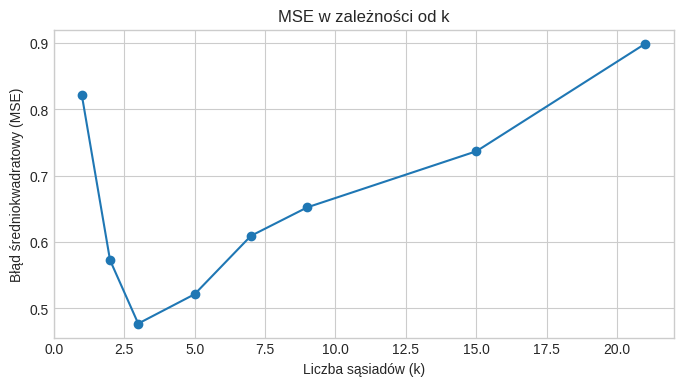

In [44]:
# Wpływ parametru k na jakość modelu (MSE na zbiorze walidacyjnym)
k_values = [1, 2, 3, 5, 7, 9, 15, 21]
mse_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k, weights='uniform')  # lub 'distance' 
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_val, model.predict(X_val))
    mse_scores.append(mse)

plt.figure(figsize=(8, 4))
plt.plot(k_values, mse_scores, marker='o')
plt.xlabel('Liczba sąsiadów (k)')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.title('MSE w zależności od k')
plt.grid(True)
plt.show()


### 4.3 sklearn Pipeline

Pipeline pozwala połączyć preprocessing (np. normalizację) z modelem w jeden obiekt.

In [45]:
# Dane bez normalizacji (surowe)
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(X, y, test_size=0.3, random_state=42)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp_raw, y_temp_raw, test_size=0.5, random_state=42)

# Pipeline: normalizacja + KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=3))
])

# Trening pipeline
pipeline.fit(X_train_raw, y_train_raw)

from sklearn.metrics import mean_squared_error
print("Pipeline (StandardScaler + KNN):")
print(f"  MSE (train): {mean_squared_error(y_train_raw, pipeline.predict(X_train_raw)):.3f}")
print(f"  MSE (val): {mean_squared_error(y_val_raw, pipeline.predict(X_val_raw)):.3f}")


Pipeline (StandardScaler + KNN):
  MSE (train): 0.291
  MSE (val): 0.470


### 4.4 Drzewo Decyzyjne (Decision Tree)


In [46]:
from sklearn.tree import DecisionTreeRegressor

# Model drzewa decyzyjnego
dt_model = DecisionTreeRegressor(random_state=42, max_depth=7)
dt_model.fit(X_train, y_train)

y_val_pred_dt = dt_model.predict(X_val)
mse_dt = mean_squared_error(y_val, y_val_pred_dt)
print(f"MSE Drzewa Decyzyjnego (Zbiór walidacyjny): {mse_dt:.4f}")

MSE Drzewa Decyzyjnego (Zbiór walidacyjny): 0.7055


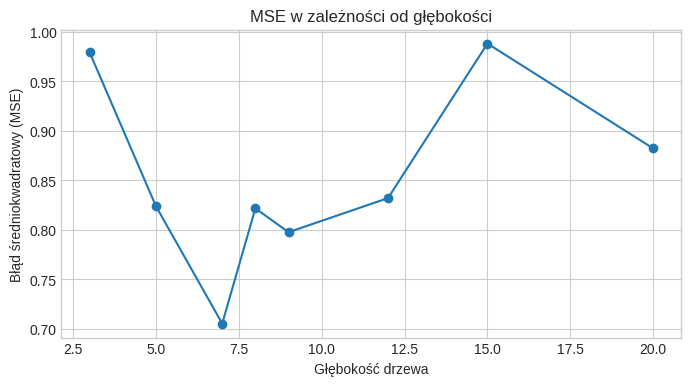

In [47]:
# Wpływ parametru głębokości na jakość modelu (MSE na zbiorze walidacyjnym)
depth_values = [3,5,7,8,9,12,15,20]
mse_scores = []

for depth in depth_values:
    model = DecisionTreeRegressor(random_state=42, max_depth=depth)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_val, model.predict(X_val))
    mse_scores.append(mse)

plt.figure(figsize=(8, 4))
plt.plot(depth_values, mse_scores, marker='o')
plt.xlabel('Głębokość drzewa')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.title('MSE w zależności od głębokości')
plt.grid(True)
plt.show()


### 4.5 Perceptron wielowarstwowy (MLP)


In [48]:
# Model MLP
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)

y_val_pred_mlp = mlp_model.predict(X_val)
from sklearn.metrics import mean_squared_error
mse_mlp = mean_squared_error(y_val, y_val_pred_mlp)
print(f"MSE MLP (Zbiór walidacyjny): {mse_mlp:.4f}")


MSE MLP (Zbiór walidacyjny): 0.4702


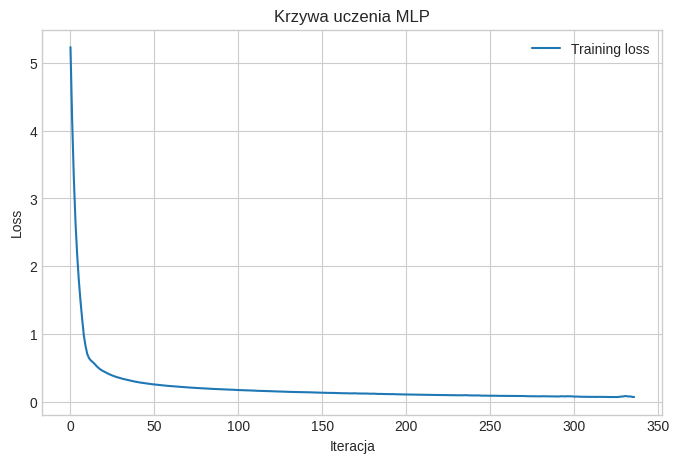

In [49]:
# Krzywa uczenia MLP
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_, label='Training loss')
plt.xlabel('Iteracja')
plt.ylabel('Loss')
plt.title('Krzywa uczenia MLP')
plt.legend()
plt.grid(True)
plt.show()

### Zadanie 4

Stwórz pipeline zawierający:
1. StandardScaler
2. MLPRegressor z architekturą (100, 50, 25)

Porównaj wyniki z poprzednim modelem MLP.

In [50]:
# Twoje rozwiązanie tutaj


---
## 5. Metryki oceny modeli

### 5.1 MSE i MAE

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) # Współczynnik determinacji wprowadzony tutaj
    
    print(f"--- {model_name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2: {r2:.4f}")
    return {'Model': model_name, 'MSE': mse, 'MAE': mae, 'R2': r2}

# Przykładowe wywołanie
calculate_metrics(y_val, y_val_pred_lr, "Regresja Liniowa (Walidacja)");


--- Regresja Liniowa (Walidacja) ---
MSE: 0.9912
MAE: 0.7669
R^2: 0.8032


**Interpretacja metryk:**
- **MSE (Mean Squared Error)**: Średni błąd kwadratowy - kara za duże błędy
- **RMSE (Root MSE)**: Pierwiastek z MSE - w tych samych jednostkach co zmienna docelowa
- **MAE (Mean Absolute Error)**: Średni błąd bezwzględny - bardziej odporny na outliers

### 5.2 Analiza kwantyli błędów

In [52]:
# Błędy absolutne na zbiorze walidacyjnym
errors_lr = np.abs(y_val - y_val_pred_lr)
errors_knn = np.abs(y_val - y_val_pred_knn)
errors_dt = np.abs(y_val - y_val_pred_dt)
errors_mlp = np.abs(y_val - y_val_pred_mlp)

# Kwantyle błędów
quantiles = [0.25, 0.5, 0.75, 0.9, 0.95]

print("Kwantyle błędów absolutnych:")
print(f"{'Kwantyl':<10} {'LR':<10} {'KNN':<10} {'DT':<10} {'MLP':<10}")
print("-" * 50)
for q in quantiles:
    print(f"{q:<10} {np.quantile(errors_lr, q):<10.3f} {np.quantile(errors_knn, q):<10.3f} {np.quantile(errors_dt, q):<10.3f} {np.quantile(errors_mlp, q):<10.3f}")


Kwantyle błędów absolutnych:
Kwantyl    LR         KNN        DT         MLP       
--------------------------------------------------
0.25       0.271      0.196      0.190      0.132     
0.5        0.670      0.379      0.508      0.353     
0.75       1.064      0.681      0.858      0.682     
0.9        1.605      1.159      1.355      1.054     
0.95       1.806      1.358      1.579      1.260     


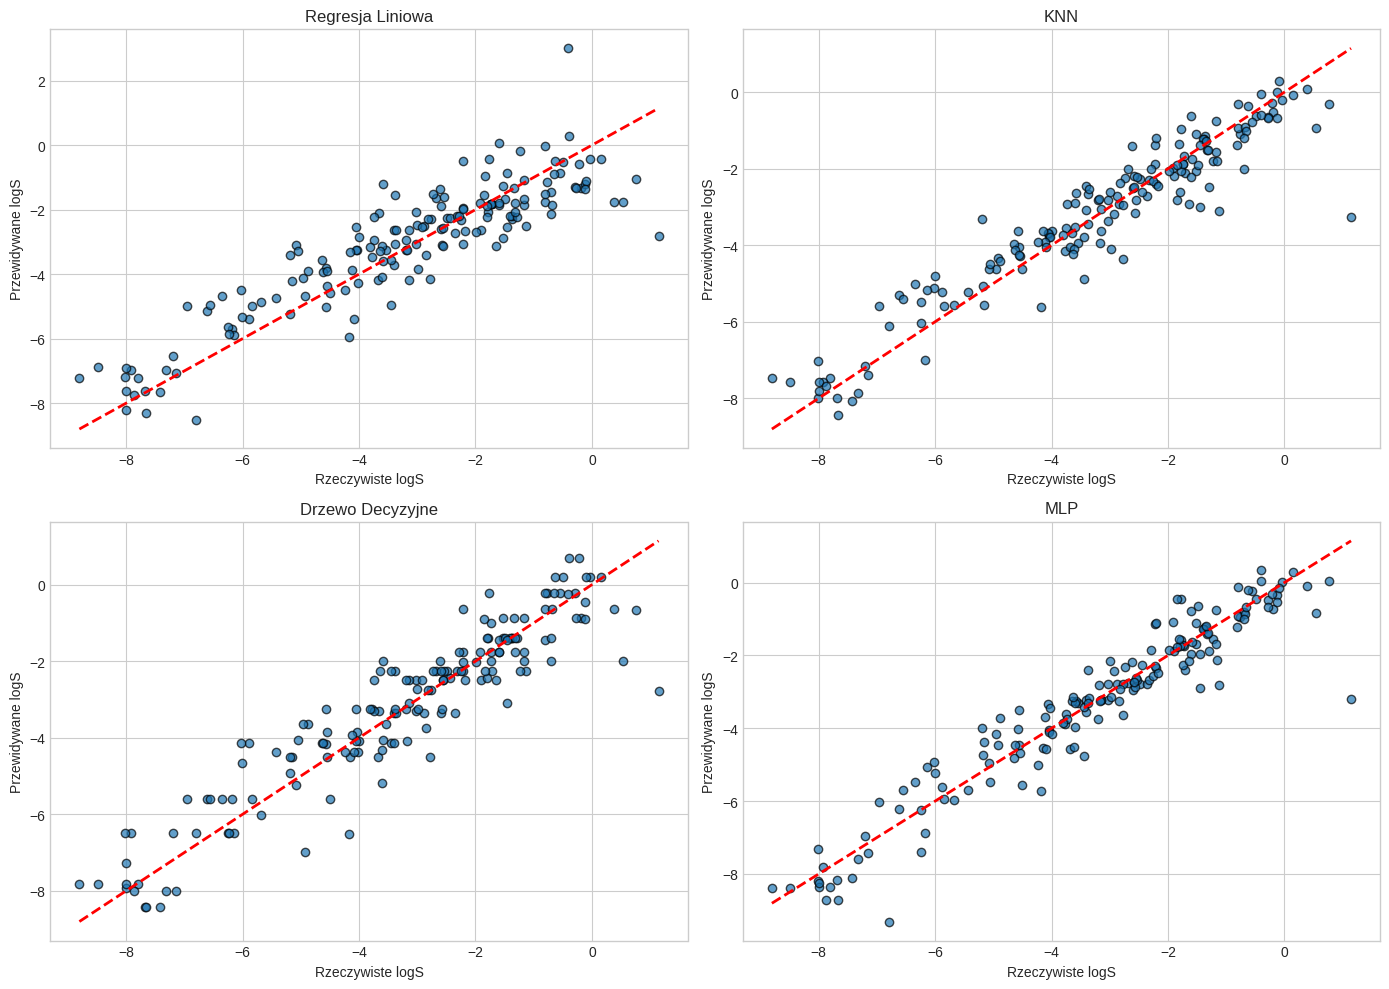

In [53]:
# Wykres porównania predykcji vs rzeczywistych wartości
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_preds = [
    ('Regresja Liniowa', y_val_pred_lr),
    ('KNN', y_val_pred_knn),
    ('Drzewo Decyzyjne', y_val_pred_dt),
    ('MLP', y_val_pred_mlp)
]

for i, (name, y_pred) in enumerate(models_preds):
    axes[i].scatter(y_val, y_pred, alpha=0.7, edgecolor='black')
    axes[i].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[i].set_xlabel('Rzeczywiste logS')
    axes[i].set_ylabel('Przewidywane logS')
    axes[i].set_title(name)
    axes[i].grid(True)

plt.tight_layout()
plt.show()


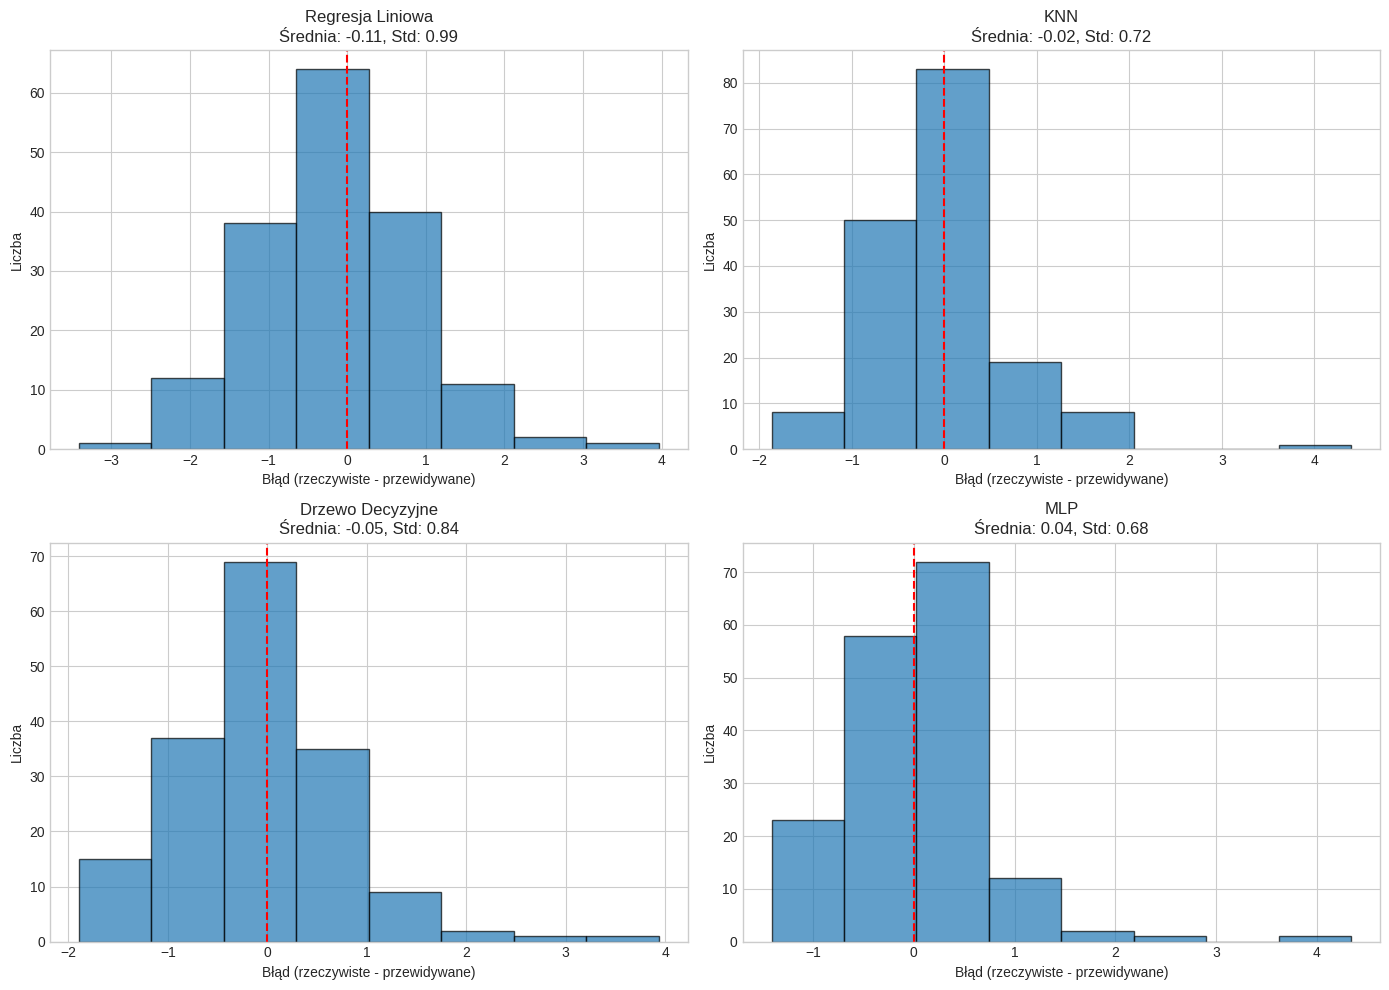

In [54]:
# Rozkład błędów
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

residuals = [
    ('Regresja Liniowa', y_val - y_val_pred_lr),
    ('KNN', y_val - y_val_pred_knn),
    ('Drzewo Decyzyjne', y_val - y_val_pred_dt),
    ('MLP', y_val - y_val_pred_mlp)
]

for i, (name, res) in enumerate(residuals):
    axes[i].hist(res, bins=8, edgecolor='black', alpha=0.7)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_xlabel('Błąd (rzeczywiste - przewidywane)')
    axes[i].set_ylabel('Liczba')
    axes[i].set_title(f'{name}\nŚrednia: {res.mean():.2f}, Std: {res.std():.2f}')

plt.tight_layout()
plt.show()


### Zadanie 5

Oblicz metrykę MAPE (Mean Absolute Percentage Error) dla wszystkich modeli. Wzór:

$$MAPE = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Uwaga: Unikaj dzielenia przez zero (możesz pominąć przypadki gdzie $y_i = 0$).

In [59]:
# Twoje rozwiązanie tutaj


---
## 6. Co dalej?

### 6.1 Inżynieria cech

W praktyce często możemy poprawić wyniki poprzez:
- Tworzenie nowych cech (np. interakcje między cechami)
- Selekcję najważniejszych cech
- Transformacje (logarytmiczne, wielomianowe)

### 5.3 Leaderboard - Ocena na zbiorze testowym

Teraz gdy wybraliśmy i dostroiliśmy modele na zbiorze walidacyjnym, sprawdzimy ich ostateczną wydajność na niespotykanym dotąd zbiorze testowym.

In [55]:
models = {
    'Regresja Liniowa': lr_model,
    'KNN': knn_model,
    'Drzewo Decyzyjne': dt_model,
    'MLP': mlp_model
}

results = []
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    results.append({'Model': name, 'Test MSE': mse, 'Test MAE': mae, 'Test R^2': r2})

leaderboard = pd.DataFrame(results).sort_values(by='Test MSE')
display(leaderboard)

,Model,Test MSE,Test MAE,Test R^2
3,MLP,0.584111,0.552615,0.857023
1,KNN,0.642705,0.575791,0.842681
2,Drzewo Decyzyjne,0.769076,0.612263,0.811748
0,Regresja Liniowa,0.916860,0.715758,0.775574


In [56]:
# Przykład: cechy wielomianowe
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_poly_sample = poly.fit_transform(X_train_raw[:5, :3])  # tylko dla demonstracji

print(f"Oryginalne cechy: {X_train_raw[:5, :3].shape}")
print(f"Po transformacji: {X_poly_sample.shape}")

Oryginalne cechy: (5, 3)
Po transformacji: (5, 6)


### 6.2 Gradient Boosting

Metody zespołowe oparte na drzewach decyzyjnych (XGBoost, LightGBM, CatBoost) często dają najlepsze wyniki na danych tabelarycznych.

In [57]:
# Przykład z GradientBoostingRegressor (wbudowany w sklearn)
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

print("Gradient Boosting:")
print(f"  MSE (train): {mean_squared_error(y_train, gb_model.predict(X_train)):.3f}")
print(f"  MSE (test): {mean_squared_error(y_test, gb_model.predict(X_test)):.3f}")

Gradient Boosting:
  MSE (train): 0.221
  MSE (test): 0.490


### 6.3 AutoML

Narzędzia AutoML automatycznie przeszukują przestrzeń modeli i hiperparametrów:
- Auto-sklearn: najbardziej zbliżony do scikit learn
- PyCaret: w pełni automatyczny, dodatkowe zadania jak 
- mljar-supervised 

```python
# Przykład użycia (nie uruchamiaj - wymaga instalacji)
# from autosklearn.regression import AutoSklearnRegressor
# automl = AutoSklearnRegressor(time_left_for_this_task=120)
# automl.fit(X_train, y_train)
```

### 6.4 Wyjaśnialność modeli (XAI)

W biofizyce i farmakologii ważne jest zrozumienie, dlaczego model podejmuje takie decyzje:
- **SHAP**: Wartości Shapleya dla interpretacji predykcji
- **LIME**: Lokalne przybliżenia modelu
- **Feature importance**: Ważność cech

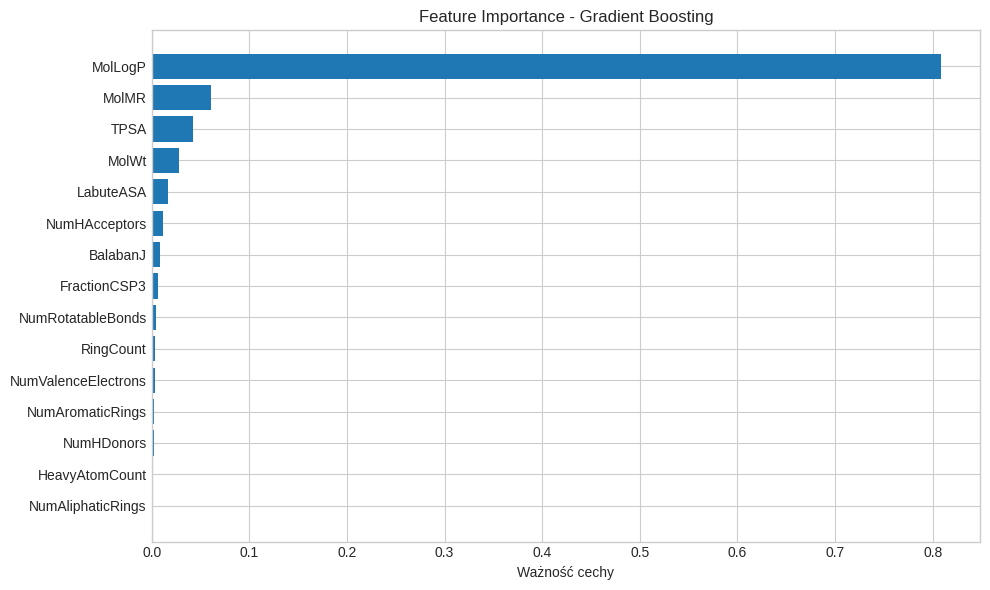

In [58]:
# Ważność cech z Gradient Boosting
feature_importance = pd.DataFrame({
    'cecha': feature_cols,
    'ważność': gb_model.feature_importances_
}).sort_values('ważność', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['cecha'], feature_importance['ważność'])
plt.xlabel('Ważność cechy')
plt.title('Feature Importance - Gradient Boosting')
plt.tight_layout()
plt.show()

In [64]:
feature_importance

,cecha,ważność
7,NumAliphaticRings,0.001494
10,HeavyAtomCount,0.001734
2,NumHDonors,0.001890
6,NumAromaticRings,0.002486
11,NumValenceElectrons,0.003188
8,RingCount,0.003727
5,NumRotatableBonds,0.003935
9,FractionCSP3,0.006001
14,BalabanJ,0.008493
3,NumHAcceptors,0.011959


array([[<Axes: xlabel='MolLogP', ylabel='MolLogP'>,
        <Axes: xlabel='MolMR', ylabel='MolLogP'>,
        <Axes: xlabel='TPSA', ylabel='MolLogP'>,
        <Axes: xlabel='MolWt', ylabel='MolLogP'>,
        <Axes: xlabel='logS', ylabel='MolLogP'>],
       [<Axes: xlabel='MolLogP', ylabel='MolMR'>,
        <Axes: xlabel='MolMR', ylabel='MolMR'>,
        <Axes: xlabel='TPSA', ylabel='MolMR'>,
        <Axes: xlabel='MolWt', ylabel='MolMR'>,
        <Axes: xlabel='logS', ylabel='MolMR'>],
       [<Axes: xlabel='MolLogP', ylabel='TPSA'>,
        <Axes: xlabel='MolMR', ylabel='TPSA'>,
        <Axes: xlabel='TPSA', ylabel='TPSA'>,
        <Axes: xlabel='MolWt', ylabel='TPSA'>,
        <Axes: xlabel='logS', ylabel='TPSA'>],
       [<Axes: xlabel='MolLogP', ylabel='MolWt'>,
        <Axes: xlabel='MolMR', ylabel='MolWt'>,
        <Axes: xlabel='TPSA', ylabel='MolWt'>,
        <Axes: xlabel='MolWt', ylabel='MolWt'>,
        <Axes: xlabel='logS', ylabel='MolWt'>],
       [<Axes: xlabel='MolLogP'

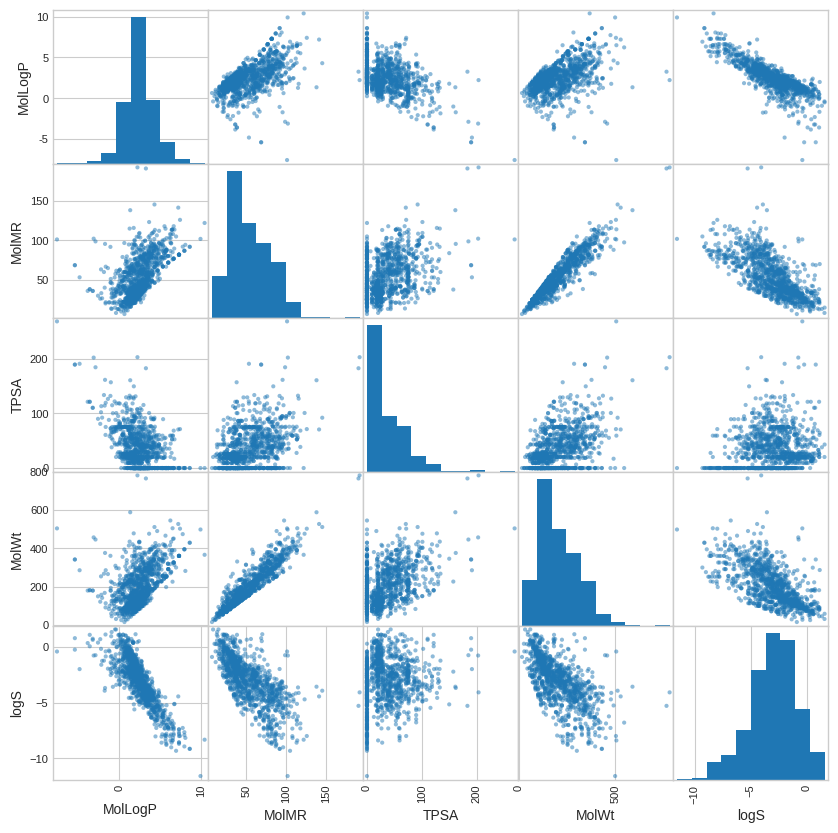

In [72]:
top_n_features = 4
pd.plotting.scatter_matrix(df_full[feature_importance["cecha"].to_list()[::-1][:top_n_features] + ['logS']], figsize=(10, 10))# plt.show()


---
## Podsumowanie

W tym ćwiczeniu nauczyliśmy się:

1. **NumPy i Pandas**: podstawowe operacje na tablicach i ramkach danych
2. **RDKit**: reprezentacja cząsteczek i ekstrakcja deskryptorów molekularnych
3. **EDA**: analiza eksploracyjna danych (statystyki, histogramy, korelacje)
4. **Preprocessing**: normalizacja, podział train/test
5. **Modele ML**: regresja liniowa, KNN, MLP, pipeline
6. **Metryki**: MSE, MAE, RMSE, kwantyle błędów

### Następne kroki:
- Eksperymentuj z większymi zbiorami danych (np. ChEMBL, PubChem)
- Wypróbuj różne deskryptory molekularne (fingerprints, ECFP)
- Poznaj gradient boosting (XGBoost, LightGBM)
- Naucz się interpretować modele (SHAP, LIME)

---
## Rozwiązania zadań

In [64]:
# Rozwiązanie Zadanie 1
arr = np.arange(1, 21)
parzyste = arr[arr % 2 == 0]  # lub arr[1::2] dla slicingu
kwadraty = parzyste ** 2
suma_kwadratow = kwadraty.sum()
print(f"Liczby parzyste: {parzyste}")
print(f"Suma kwadratów: {suma_kwadratow}")

df_kwadraty = pd.DataFrame({'kwadraty': kwadraty})
df_kwadraty

Liczby parzyste: [ 2  4  6  8 10 12 14 16 18 20]
Suma kwadratów: 1540


,kwadraty
0,4
1,16
2,36
3,64
4,100
5,144
6,196
7,256
8,324
9,400


In [65]:
# Rozwiązanie Zadanie 2
lipinski_descriptors_names = [name for name, desc in lipinski_descriptors]

calc = MoleculeDescriptors.MolecularDescriptorCalculator(lipinski_descriptors_names)

# Obliczenie deskryptorów dla wszystkich cząsteczek
descriptors_data = []
for mol in df['mol']:
    descriptors_data.append(calc.CalcDescriptors(mol))

# Utworzenie DataFrame z deskryptorami
df_descriptors = pd.DataFrame(descriptors_data, columns=lipinski_descriptors_names)
df_descriptors.head()

array([[<Axes: xlabel='MolWt', ylabel='MolWt'>,
        <Axes: xlabel='MolLogP', ylabel='MolWt'>,
        <Axes: xlabel='TPSA', ylabel='MolWt'>,
        <Axes: xlabel='logS', ylabel='MolWt'>],
       [<Axes: xlabel='MolWt', ylabel='MolLogP'>,
        <Axes: xlabel='MolLogP', ylabel='MolLogP'>,
        <Axes: xlabel='TPSA', ylabel='MolLogP'>,
        <Axes: xlabel='logS', ylabel='MolLogP'>],
       [<Axes: xlabel='MolWt', ylabel='TPSA'>,
        <Axes: xlabel='MolLogP', ylabel='TPSA'>,
        <Axes: xlabel='TPSA', ylabel='TPSA'>,
        <Axes: xlabel='logS', ylabel='TPSA'>],
       [<Axes: xlabel='MolWt', ylabel='logS'>,
        <Axes: xlabel='MolLogP', ylabel='logS'>,
        <Axes: xlabel='TPSA', ylabel='logS'>,
        <Axes: xlabel='logS', ylabel='logS'>]], dtype=object)

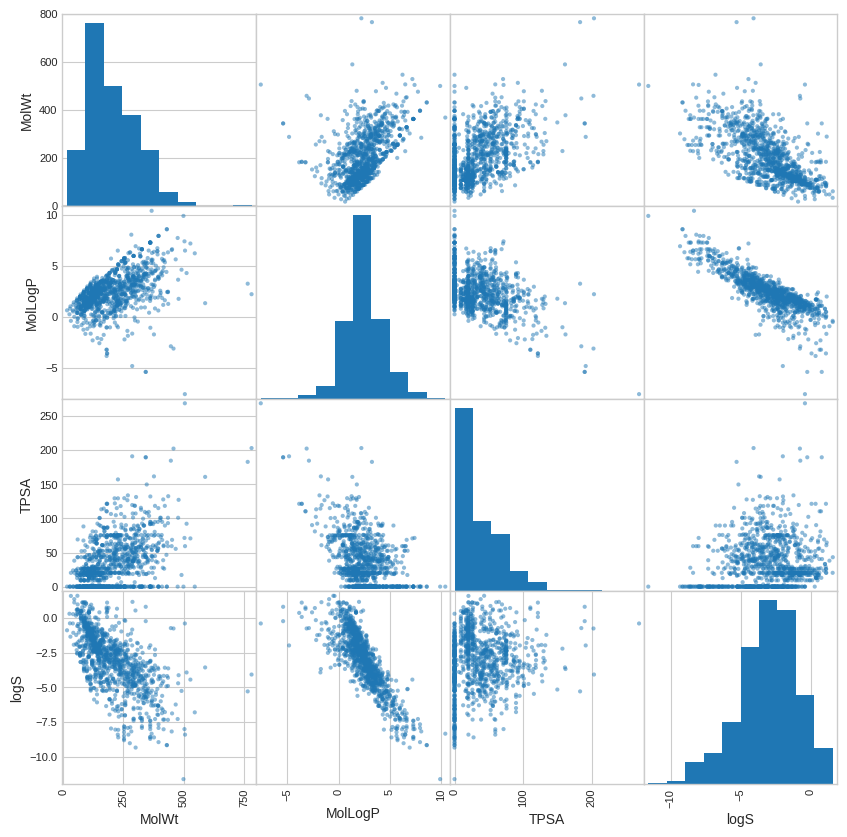

In [209]:
# Rozwiązanie Zadanie 3
# Scatter plot dla najbardziej skorelowanych zmiennych
pd.plotting.scatter_matrix(df_full[['MolWt', 'MolLogP', 'TPSA', 'logS']], figsize=(10, 10))# plt.show()


In [233]:
# Rozwiązanie Zadanie 4
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(100, 50, 25), max_iter=1000, random_state=42))
])

pipeline_mlp.fit(X_train_raw, y_train)

print("Pipeline MLP (100, 50, 25):")
print(f"  MSE (train): {mean_squared_error(y_train_raw, pipeline_mlp.predict(X_train_raw)):.3f}")
print(f"  MSE (test): {mean_squared_error(y_test_raw, pipeline_mlp.predict(X_test_raw)):.3f}")

Pipeline MLP (100, 50, 25):
  MSE (train): 0.075
  MSE (test): 0.616


In [234]:
# Rozwiązanie Zadanie 5
def mape(y_true, y_pred):
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

print("MAPE (Mean Absolute Percentage Error):")
print(f"  Regresja Liniowa: {mape(y_val, y_val_pred_lr):.1f}%")
print(f"  KNN: {mape(y_val, y_val_pred_knn):.1f}%")
print(f"  Drzewo Decyzyjne: {mape(y_val, y_val_pred_dt):.1f}%")
print(f"  MLP: {mape(y_val, y_val_pred_mlp):.1f}%")


MAPE (Mean Absolute Percentage Error):
  Regresja Liniowa: 75.3%
  KNN: 36.5%
  Drzewo Decyzyjne: 47.8%
  MLP: 30.5%
